In [1]:
import pathlib, os, sys, datetime

# Pastikan notebook dijalankan dari folder notebooks/
NOTEBOOK_DIR = pathlib.Path.cwd()
if not (NOTEBOOK_DIR / '..' / 'data').exists():
    raise RuntimeError("Jalankan notebook ini dari folder 'notebooks/' agar path ke data ditemukan.")

PROJECT_ROOT = (NOTEBOOK_DIR / '..').resolve()
print(f"Project root: {PROJECT_ROOT}")

DATA_DIR       = PROJECT_ROOT / 'data'
DATASET_DIR    = DATA_DIR / 'dataset'           # sumber mentah
CLEAN_DIR      = DATA_DIR / 'dataset_clean'     # hasil crop & enhance
MODEL_DIR      = PROJECT_ROOT / 'models'
OUTPUT_DIR     = PROJECT_ROOT / 'output'

# Konfigurasi training
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16          # sesuaikan dengan VRAM (6 GB aman di 16)
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 10
LEARNING_RATE_HEAD = 0.001
LEARNING_RATE_FT = 0.00001
USE_MIXED_PRECISION = False   # mixed precision dimatikan untuk kompatibilitas

# Flag logging
VERBOSE = True


Project root: E:\AIC\BlockchainAI


In [2]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Folder dataset mentah tidak ditemukan: {DATASET_DIR}")
print(f"Dataset mentah ditemukan: {DATASET_DIR}")

# Buat folder output jika belum ada
os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Sesi dimulai: {datetime.datetime.now()}")
with open(OUTPUT_DIR / 'training_log.txt', 'a') as f:
    f.write(f"Sesi dimulai: {datetime.datetime.now()}\n")


Dataset mentah ditemukan: E:\AIC\BlockchainAI\data\dataset
Sesi dimulai: 2026-07-08 22:37:32.910650


In [3]:
%pip install tensorflow

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU ditemukan: {gpus}")
    # Coba aktifkan memory growth untuk setiap GPU
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass
else:
    print("WARNING: Tidak ada GPU, training akan lambat.")

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")
# Catat versi ke log
with open(OUTPUT_DIR / 'training_log.txt', 'a') as f:
    f.write(f"TF {tf.__version__}, Keras {tf.keras.__version__}\n")

if USE_MIXED_PRECISION and gpus:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision diaktifkan (FP16).")
    except Exception as e:
        print(f"Mixed precision tidak didukung: {e}")
else:
    print("Mixed precision tidak diaktifkan.")


     ---------------------------------------- 0.0/350.6 MB ? eta -:--:--
     ---------------------------------------- 0.1/350.6 MB 1.1 MB/s eta 0:05:22
     ---------------------------------------- 0.2/350.6 MB 1.8 MB/s eta 0:03:19
     ---------------------------------------- 0.4/350.6 MB 2.6 MB/s eta 0:02:17
     ---------------------------------------- 0.8/350.6 MB 4.1 MB/s eta 0:01:26
     ---------------------------------------- 1.5/350.6 MB 6.2 MB/s eta 0:00:57
     ---------------------------------------- 2.6/350.6 MB 9.1 MB/s eta 0:00:39
      -------------------------------------- 4.7/350.6 MB 14.2 MB/s eta 0:00:25
      -------------------------------------- 6.1/350.6 MB 16.2 MB/s eta 0:00:22
      -------------------------------------- 8.4/350.6 MB 19.9 MB/s eta 0:00:18
     - ------------------------------------ 10.9/350.6 MB 36.4 MB/s eta 0:00:10
     - ------------------------------------ 13.4/350.6 MB 46.9 MB/s eta 0:00:08
     - ------------------------------------ 15.


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow version: 2.21.0
Keras version: 3.12.3
Mixed precision tidak diaktifkan.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm import tqdm

# Tambahkan path root ke sys.path agar bisa import dari src
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
from src.preprocessing import find_medicine_package, crop_and_enhance

print("✅ Library dan modul preprocessing siap.")


✅ Library dan modul preprocessing siap.


In [5]:
def prepare_clean_dataset():
    clean_asli_dir = CLEAN_DIR / 'asli'
    clean_palsu_dir = CLEAN_DIR / 'palsu'
    os.makedirs(clean_asli_dir, exist_ok=True)
    os.makedirs(clean_palsu_dir, exist_ok=True)

    total = 0
    failed = 0

    for folder, clean_dir in [('asli', clean_asli_dir), ('palsu', clean_palsu_dir)]:
        raw_dir = DATASET_DIR / folder
        print(f"MEMPROSES FOLDER {folder.upper()}")
        if not raw_dir.exists():
            print(f"Folder {raw_dir} tidak ditemukan, lewati.")
            continue

        for fname in tqdm(os.listdir(raw_dir)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                img = cv2.imread(str(raw_dir / fname))
                if img is None:
                    failed += 1
                    continue

                rect = find_medicine_package(img)
                if rect is None:
                    failed += 1

                enhanced = crop_and_enhance(img, rect, img_height=IMG_HEIGHT, img_width=IMG_WIDTH)
                cv2.imwrite(str(clean_dir / fname), enhanced)
                total += 1

    # Tulis statistik ke log
    with open(OUTPUT_DIR / 'training_log.txt', 'a') as f:
        f.write(f"{datetime.datetime.now()} - prepare_clean_dataset: total={total}, failed={failed}\n")

    print(f"Total diproses: {total}")
    print(f"Gagal deteksi (tapi tetap diproses): {failed}")
    return total, failed, []


In [6]:
def train_model_on_clean_dataset():
    dataset_path = str(CLEAN_DIR)
    batch_size = BATCH_SIZE

    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset='training',
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        label_mode='binary',
        class_names=['asli', 'palsu']
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset='validation',
        seed=123,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        label_mode='binary',
        class_names=['asli', 'palsu']
    )

    # Augmentasi ringan
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomBrightness(0.1),
        tf.keras.layers.RandomContrast(0.1),
    ])

    normalization_layer = tf.keras.layers.Rescaling(1./255)

    train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
    train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
    val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

    # Class weights
    count_asli = len(os.listdir(CLEAN_DIR / 'asli'))
    count_palsu = len(os.listdir(CLEAN_DIR / 'palsu'))
    total_samples = count_asli + count_palsu
    weight_asli = total_samples / (2 * count_asli) if count_asli > 0 else 1.0
    weight_palsu = total_samples / (2 * count_palsu) if count_palsu > 0 else 1.0
    class_weight = {0: weight_asli, 1: weight_palsu}
    print(f"Class weights: {class_weight}")

    # Build model
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD)
    if USE_MIXED_PRECISION:
        optimizer = tf.keras.mixed_precision.LossScaleOptimizer(optimizer)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_DIR / 'panadol_v4_clean_best.h5'),
        monitor='val_loss',
        save_best_only=True
    )

    # Tahap 1: Train head only
    print("\n" + "="*60)
    print("TAHAP 1: TRAINING HEAD ONLY")
    print("="*60)
    history1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE1,
        class_weight=class_weight,
        callbacks=[early_stop, checkpoint]
    )

    # Tahap 2: Fine-tuning
    print("\n" + "="*60)
    print("TAHAP 2: FINE-TUNING")
    print("="*60)
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    optimizer_ft = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FT)
    if USE_MIXED_PRECISION:
        optimizer_ft = tf.keras.mixed_precision.LossScaleOptimizer(optimizer_ft)

    model.compile(
        optimizer=optimizer_ft,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history2 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE2,
        class_weight=class_weight,
        callbacks=[early_stop, checkpoint]
    )

    # Gabungkan history
    full_history = {}
    for key in history1.history:
        full_history[key] = history1.history[key] + history2.history[key]

    # Plot
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(full_history['accuracy'], label='Train')
    plt.plot(full_history['val_accuracy'], label='Validasi')
    plt.legend(); plt.title('Akurasi')
    plt.subplot(1,2,2)
    plt.plot(full_history['loss'], label='Train')
    plt.plot(full_history['val_loss'], label='Validasi')
    plt.legend(); plt.title('Loss')
    plt.show()

    loss, acc = model.evaluate(val_ds)
    print(f"Validation Accuracy: {acc*100:.2f}%")

    # ======================= PENYIMPANAN MODEL (Jalur A) =======================
    # 1. Format native Keras 3
    keras_path = str(MODEL_DIR / 'panadol_v4_clean.keras')
    model.save(keras_path)
    print(f"✅ Model Keras disimpan: {keras_path}")

    # 2. SavedModel (menggunakan tf.saved_model.save, tanpa save_format)
    savedmodel_dir = str(MODEL_DIR / 'panadol_v4_clean_savedmodel')
    tf.saved_model.save(model, savedmodel_dir)
    print(f"✅ Model SavedModel disimpan: {savedmodel_dir}")

    # 3. H5 sebagai cadangan
    h5_path = str(MODEL_DIR / 'panadol_v4_clean.h5')
    model.save(h5_path)
    print(f"✅ Model H5 disimpan: {h5_path}")

    # Konversi ke TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(str(MODEL_DIR / 'panadol_v4_clean.tflite'), 'wb') as f:
        f.write(tflite_model)
    print(f"✅ Model TFLite disimpan: {MODEL_DIR / 'panadol_v4_clean.tflite'}")

    # Logging metrik akhir
    with open(OUTPUT_DIR / 'training_log.txt', 'a') as f:
        f.write(f"{datetime.datetime.now()} - Training selesai, val_accuracy={acc*100:.2f}%\n")

    return model, full_history


In [7]:
# ======================= PEMUATAN MODEL (Jalur A) =======================
keras_path = str(MODEL_DIR / 'panadol_v4_clean.keras')
savedmodel_path = str(MODEL_DIR / 'panadol_v4_clean_savedmodel')
h5_path = str(MODEL_DIR / 'panadol_v4_clean.h5')

verify_model = None
paths_to_try = [keras_path, savedmodel_path, h5_path]

for path in paths_to_try:
    if os.path.exists(path):
        try:
            verify_model = tf.keras.models.load_model(path)
            print(f"✅ Model dimuat dari: {path}")
            break
        except Exception as e:
            print(f"⚠️ Gagal memuat dari {path}: {e}")
            continue
else:
    print("❌ Tidak ada model yang berhasil dimuat. Jalankan training terlebih dahulu.")

def predict_medicine(image_path, threshold=0.5, confidence_floor=0.80, white_ratio_min=0.03, min_text_blobs=3):
    if verify_model is None:
        return "ERROR", "Model tidak tersedia. Tidak dapat melakukan inferensi.", 0.0, None

    img = cv2.imread(image_path)
    if img is None:
        return "ERROR", "Gambar tidak ditemukan", 0.0, None

    original = img.copy()
    rect = find_medicine_package(img)
    if rect is None:
        rect = (0, 0, img.shape[1], img.shape[0])

    enhanced = crop_and_enhance(img, rect, img_height=IMG_HEIGHT, img_width=IMG_WIDTH)
    if enhanced is None:
        return "ERROR", "Gagal memproses gambar", 0.0, original

    img_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
    img_array = np.expand_dims(img_rgb, axis=0) / 255.0
    pred = verify_model.predict(img_array, verbose=0)[0][0]

    if pred >= threshold:
        label = "❌ PALSU"
        confidence = pred
    else:
        label = "✅ ASLI"
        confidence = 1.0 - pred

    if confidence < confidence_floor:
        return "DITOLAK", "❌ Objek tidak dikenal / bukan obat", confidence, enhanced

    hsv = cv2.cvtColor(enhanced, cv2.COLOR_BGR2HSV)
    mask_white = cv2.inRange(hsv, (0, 0, 180), (180, 50, 255))
    white_ratio = np.sum(mask_white > 0) / mask_white.size

    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    text_blobs = sum(1 for cnt in contours if 50 < cv2.contourArea(cnt) < 5000)

    has_white = white_ratio >= white_ratio_min
    has_text = text_blobs >= min_text_blobs

    if not (has_white or has_text):
        return "DITOLAK", "❌ Objek bukan obat / tidak ada ciri kemasan", confidence, enhanced

    return "TERVERIFIKASI", label, confidence, enhanced


def predict_and_display(image_path, threshold=0.5):
    if verify_model is None:
        print("Model tidak dimuat. Tidak dapat melakukan inferensi.")
        return

    status, label, confidence, enhanced = predict_medicine(image_path, threshold)

    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Gambar Asli")
    plt.axis('off')

    if enhanced is not None:
        enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 2, 2)
        plt.imshow(enhanced_rgb)
        plt.title("Hasil Crop & Enhance")
        plt.axis('off')

    plt.suptitle(f"{label}\nConfidence: {confidence*100:.2f}%", fontsize=14)
    plt.show()

    print("="*60)
    print(f"File    : {os.path.basename(image_path)}")
    print(f"Status  : {status}")
    print(f"Hasil   : {label}")
    print(f"Confidence: {confidence*100:.2f}%")
    print("="*60)

    return status, label, confidence


✅ Model dimuat dari: E:\AIC\BlockchainAI\models\panadol_v4_clean.h5


LANGKAH 1: PERSIAPAN DATASET BERSIH (CROP & ENHANCE)
MEMPROSES FOLDER ASLI


100%|██████████| 517/517 [01:11<00:00,  7.24it/s]


MEMPROSES FOLDER PALSU


100%|██████████| 197/197 [00:25<00:00,  7.67it/s]


Total diproses: 714
Gagal deteksi (tapi tetap diproses): 161

LANGKAH 2: TRAINING MODEL VERIFIKASI
Found 2063 files belonging to 2 classes.
Using 1651 files for training.
Found 2063 files belonging to 2 classes.
Using 412 files for validation.
Class weights: {0: 0.7523705324580598, 1: 1.490606936416185}

TAHAP 1: TRAINING HEAD ONLY
Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.6272 - loss: 0.6975

...

104/104 ━━━━━━━━━━━━━━━━━━━━ 81s 607ms/step - accuracy: 0.8988 - loss: 0.2426 - val_accuracy: 0.9417 - val_loss: 0.1354
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.9126 - loss: 0.2280

104/104 ━━━━━━━━━━━━━━━━━━━━ 63s 601ms/step - accuracy: 0.9134 - loss: 0.2027 - val_accuracy: 0.9442 - val_loss: 0.1208
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9116 - loss: 0.1943

104/104 ━━━━━━━━━━━━━━━━━━━━ 56s 539ms/step - accuracy: 0.9128 - loss: 0.1955 - val_accuracy: 0.9563 - val_loss: 0.1057
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 62s 589ms/step - accuracy: 0.9303 - loss: 0.1664 - val_accuracy: 0.9612 - val_loss: 0.1074
Epoch 9/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.9542 - loss: 0.1221

104/104 ━━━━━━━━━━━━━━━━━━━━ 62s 596ms/step - accuracy: 0.9419 - loss: 0.1561 - val_accuracy: 0.9612 - val_loss: 0.0969
Epoch 10/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.9439 - loss: 0.1318

104/104 ━━━━━━━━━━━━━━━━━━━━ 83s 600ms/step - accuracy: 0.9509 - loss: 0.1287 - val_accuracy: 0.9660 - val_loss: 0.0943


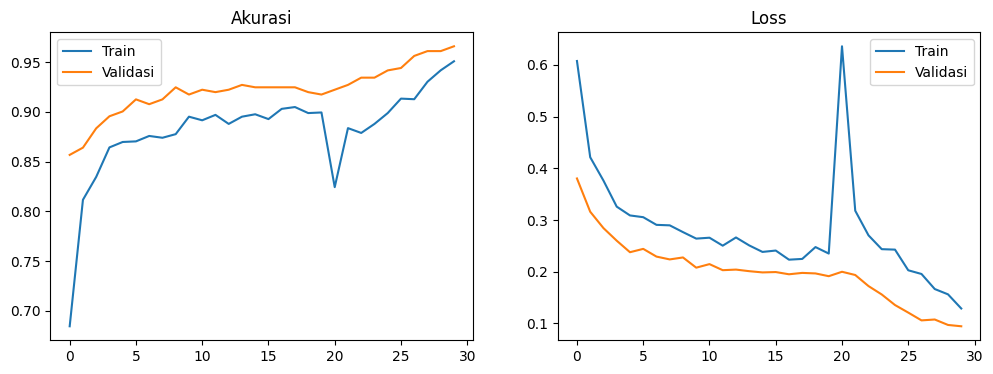

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.9660 - loss: 0.0943
Validation Accuracy: 96.60%
✅ Model Keras disimpan: E:\AIC\BlockchainAI\models\panadol_v4_clean.keras
INFO:tensorflow:Assets written to: E:\AIC\BlockchainAI\models\panadol_v4_clean_savedmodel\assets


INFO:tensorflow:Assets written to: E:\AIC\BlockchainAI\models\panadol_v4_clean_savedmodel\assets


✅ Model SavedModel disimpan: E:\AIC\BlockchainAI\models\panadol_v4_clean_savedmodel
✅ Model H5 disimpan: E:\AIC\BlockchainAI\models\panadol_v4_clean.h5
INFO:tensorflow:Assets written to: C:\Users\acern\AppData\Local\Temp\tmp_gmxr9ap\assets


INFO:tensorflow:Assets written to: C:\Users\acern\AppData\Local\Temp\tmp_gmxr9ap\assets


Saved artifact at 'C:\Users\acern\AppData\Local\Temp\tmp_gmxr9ap'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_486')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2531084984816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752997152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752994336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529753000496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529753005600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752996096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752971952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752963328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752969488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2529752959984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2

In [8]:
print("="*70)
print("LANGKAH 1: PERSIAPAN DATASET BERSIH (CROP & ENHANCE)")
print("="*70)
total, failed, _ = prepare_clean_dataset()

print("\n" + "="*70)
print("LANGKAH 2: TRAINING MODEL VERIFIKASI")
print("="*70)
model, history = train_model_on_clean_dataset()

print("\n✅ Pelatihan selesai! Model disimpan di folder models/")


In [ ]:
end_time = datetime.datetime.now()
print(f"Sesi berakhir: {end_time}")
with open(OUTPUT_DIR / 'training_log.txt', 'a') as f:
    f.write(f"Sesi selesai: {end_time}\n")


Sesi berakhir: 2026-07-08 23:10:43.157179


: 